libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings .filterwarnings('ignore')




data load



In [2]:
df = pd.read_csv('../data/online_payments_fraud.csv')
print(df.shape)


(6362620, 11)


In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


EDA



In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.shape


(6362620, 11)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [10]:
print("Fraud vs Legit count:")
print(df['isFraud'].value_counts())

print("\nPercentage :")
print(df['isFraud'].value_counts(normalize=True) * 100)

Fraud vs Legit count:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentage :
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

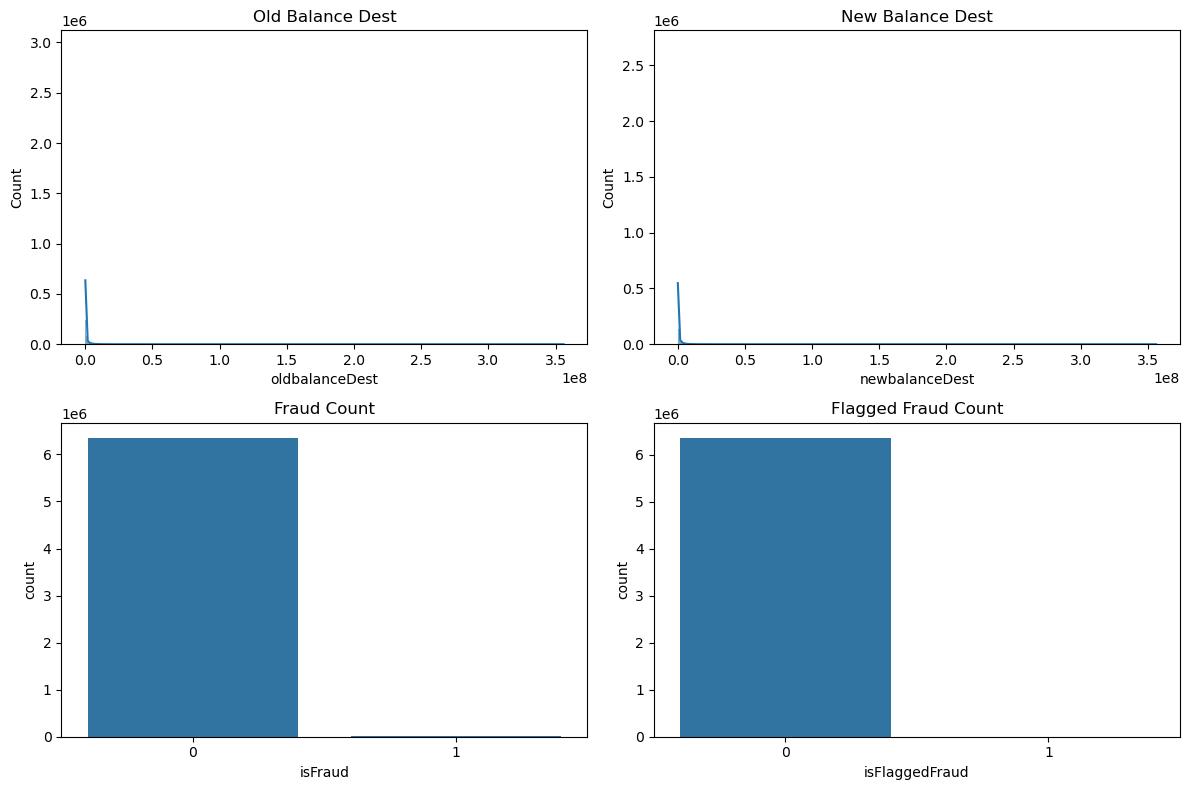

In [12]:

plt.figure(figsize=(12, 8))

# Graph 1 - oldbalanceDest
plt.subplot(2, 2, 1)
sns.histplot(df['oldbalanceDest'], kde=True)
plt.title('Old Balance Dest')

# Graph 2 - newbalanceDest  
plt.subplot(2, 2, 2)
sns.histplot(df['newbalanceDest'], kde=True)
plt.title('New Balance Dest')

# Graph 3 - isFraud
plt.subplot(2, 2, 3)
sns.countplot(x='isFraud', data=df)
plt.title('Fraud Count')

# Graph 4 - isFlaggedFraud
plt.subplot(2, 2, 4)
sns.countplot(x='isFlaggedFraud', data=df)
plt.title('Flagged Fraud Count')

plt.tight_layout()
plt.show()

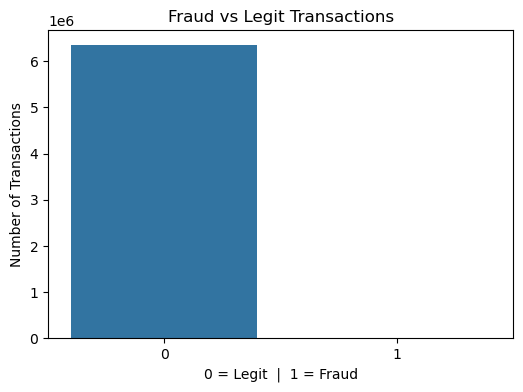

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df)

plt.title('Fraud vs Legit Transactions')
plt.xlabel('0 = Legit  |  1 = Fraud')
plt.ylabel('Number of Transactions')

plt.show()

In [14]:
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

print("Columns after dropping:")
print(df.columns.tolist())

Columns after dropping:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


In [15]:
# Filter  CASH_OUT or TRANSFER 
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])]


print("Shape after filtering:", df.shape)


print("\nFraud count:")
print(df['isFraud'].value_counts())

Shape after filtering: (2770409, 8)

Fraud count:
isFraud
0    2762196
1       8213
Name: count, dtype: int64


Encoding

In [16]:
#Encoding
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print("Type column after encoding:")
print(df['type'].value_counts())


Type column after encoding:
type
0    2237500
1     532909
Name: count, dtype: int64


In [17]:

# X = features (input)
# y = target (output)
from sklearn.model_selection import train_test_split

X = df.drop(columns=['isFraud'])
y = df['isFraud']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain fraud %:", round(y_train.mean() * 100, 2), "%")
print("Test fraud %:", round(y_test.mean() * 100, 2), "%")


X_train shape: (2216327, 7)
X_test shape: (554082, 7)

Train fraud %: 0.3 %
Test fraud %: 0.3 %


In [18]:
# New Features 
df['balanceOrig_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

df['zero_oldbalanceDest'] = (df['oldbalanceDest'] == 0).astype(int)
df['zero_newbalanceDest'] = (df['newbalanceDest'] == 0).astype(int)

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

SMOTE


In [19]:
# SMOTE 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())
#train smote
X_train_sm, y_train_sm = smote.fit_resample(
    X_train, y_train
)
# After SMOTE
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


Before SMOTE:
isFraud
0    2209757
1       6570
Name: count, dtype: int64

After SMOTE:
isFraud
0    2209757
1    2209757
Name: count, dtype: int64


SMOTE Graph

 


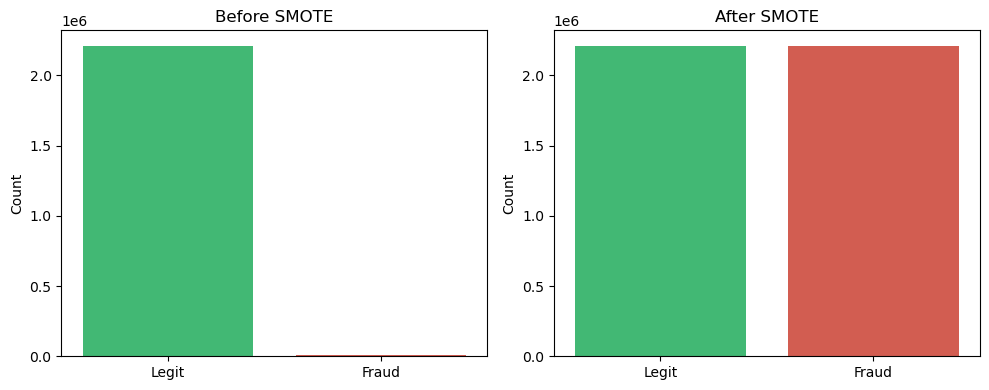

In [20]:
# Before and After SMOTE - 2 graphs
plt.figure(figsize=(10, 4))

# Graph 1 - Before SMOTE
plt.subplot(1, 2, 1)
sns.barplot(x=['Legit', 'Fraud'], 
            y=[2209757, 6570],
            palette=['#2ecc71', '#e74c3c'])
plt.title('Before SMOTE')
plt.ylabel('Count')

# Graph 2 - After SMOTE
plt.subplot(1, 2, 2)
sns.barplot(x=['Legit', 'Fraud'], 
            y=[2209757, 2209757],
            palette=['#2ecc71', '#e74c3c'])
plt.title('After SMOTE')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

Logistic Regression


In [23]:
# Model 1 - Logistic Regression
from sklearn.linear_model import LogisticRegression

# Model 
lr_model = LogisticRegression(max_iter=1000, 
                               random_state=42)

# Model train
lr_model.fit(X_train_sm, y_train_sm)

print("Logistic Regression training done!")

Logistic Regression training done!


In [24]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X_train_lr = X_train_sm[:100000]
y_train_lr = y_train_sm[:100000]

lr_model_new = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced'
)

lr_model_new.fit(X_train_lr, y_train_lr)
y_pred_lr_new = lr_model_new.predict(X_test)

print("Logistic Regression - Improved:")
print(classification_report(y_test, y_pred_lr_new,
      target_names=['Legit', 'Fraud']))


Logistic Regression - Improved:
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98    552439
       Fraud       0.06      0.89      0.12      1643

    accuracy                           0.96    554082
   macro avg       0.53      0.92      0.55    554082
weighted avg       1.00      0.96      0.98    554082



Random Forest

In [25]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model3 = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model3.fit(X_train_sm, y_train_sm)
y_pred_rf3 = rf_model3.predict(X_test)

print("Random Forest - Final:")
print(classification_report(y_test, y_pred_rf3,
      target_names=['Legit', 'Fraud']))


Random Forest - Final:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.69      0.93      0.79      1643

    accuracy                           1.00    554082
   macro avg       0.84      0.96      0.89    554082
weighted avg       1.00      1.00      1.00    554082



SVM

In [26]:
# ─── SVM ────
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

# Step 1 - Data 
X_train_svm = X_train_sm[:300000]
y_train_svm = y_train_sm[:300000]

print(f'Train size: {X_train_svm.shape}')
print(f'Fraud %: {y_train_svm.mean()*100:.1f}%')

# Step 2 - Scale 
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled  = scaler_svm.transform(X_test)

print('Scaling done!')

# Step 3 - LinearSVC + Calibration
svm_base = LinearSVC(
    class_weight='balanced',
    C=0.1,
    max_iter=3000,
    random_state=42
)

svm_model3 = CalibratedClassifierCV(svm_base, cv=3)

# Step 4 - Train 
print('Training... (1-2 min lagega)')
svm_model3.fit(X_train_svm_scaled, y_train_svm)
print(' Training done!')

# Step 5 - Probability lo
y_prob_svm3 = svm_model3.predict_proba(X_test_svm_scaled)[:, 1]

# Step 6 - Optimal threshold 
precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_prob_svm3
)
f1_vals = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-8)
)
best_thresh = thresholds[np.argmax(f1_vals)]
print(f'Best threshold: {best_thresh:.4f}')

# Step 7 - Final prediction
y_pred_svm3 = (y_prob_svm3 >= best_thresh).astype(int)

# Step 8 - Results
print('\nSVM - Improved:')
print(classification_report(
    y_test,
    y_pred_svm3,
    target_names=['Legit', 'Fraud']
))

print('='*38)

Train size: (300000, 7)
Fraud %: 0.3%
Scaling done!
Training... (1-2 min lagega)
 Training done!
Best threshold: 0.3298

SVM - Improved:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.80      0.50      0.62      1643

    accuracy                           1.00    554082
   macro avg       0.90      0.75      0.81    554082
weighted avg       1.00      1.00      1.00    554082



Neural Network

In [27]:
# Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Step 1 - 
X_train_nn = X_train_sm[:100000]
y_train_nn = y_train_sm[:100000]

# Step 2 - Scale 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nn)
X_test_scaled = scaler.transform(X_test)

# Step 3 - Better model
nn_model3 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    max_iter=200,                      
    random_state=42,
    early_stopping=True,
    learning_rate='adaptive',         
    verbose=False
)

# Train 
nn_model3.fit(X_train_scaled, y_train_nn)

# Test
y_pred_nn3 = nn_model3.predict(X_test_scaled)

# Results 
print("Neural Network - ")
print(classification_report(y_test, y_pred_nn3,
      target_names=['Legit', 'Fraud']))

# Neural Network - Threshold Fix
from sklearn.metrics import classification_report

# Probability 
y_prob_nn = nn_model3.predict_proba(X_test_scaled)[:, 1]



Neural Network - 
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.85      0.70      0.77      1643

    accuracy                           1.00    554082
   macro avg       0.92      0.85      0.88    554082
weighted avg       1.00      1.00      1.00    554082



Decision Tress


In [28]:
# Model 5 - Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Model 
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=15,           
    min_samples_split=10,   
    min_samples_leaf=5,     
    criterion='gini'        
)

# Train 
dt_model.fit(X_train_sm, y_train_sm)

# Test 
y_pred_dt = dt_model.predict(X_test)

# Results 
print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Legit', 'Fraud']))


Decision Tree Results:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.45      0.97      0.62      1643

    accuracy                           1.00    554082
   macro avg       0.73      0.98      0.81    554082
weighted avg       1.00      1.00      1.00    554082



xgboost


In [29]:

!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler


# Step 1 - Scale 
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_sm)
X_test_xgb_scaled  = scaler_xgb.transform(X_test)

# Step 2 - Better model
xgb_model = XGBClassifier(
    n_estimators=300,         
    max_depth=8,               
    learning_rate=0.05,        
    scale_pos_weight=len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1]),
    subsample=0.8,             # overfitting
    colsample_bytree=0.8,      # overfitting 
    min_child_weight=5,
    gamma=1,
    random_state=42,
    tree_method='hist',
    verbosity=0
)

# Step 3 - Train
print('Training... ')
xgb_model.fit(X_train_xgb_scaled, y_train_sm)
print(' Done!')

# Step 4 - Probability
y_prob_xgb = xgb_model.predict_proba(X_test_xgb_scaled)[:, 1]

# Step 5 - Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_vals = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-8)
)
best_thresh = thresholds[np.argmax(f1_vals)]
print(f'Best threshold: {best_thresh:.4f}')

# Step 6 - Prediction
y_pred_xgb = (y_prob_xgb >= best_thresh).astype(int)

# Step 7 - Results
print('\nXGBoost - Improved:')
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))

Training... 
 Done!
Best threshold: 0.9810

XGBoost - Improved:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.95      0.89      0.92      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.95      0.96    554082
weighted avg       1.00      1.00      1.00    554082



MODELS - ASCENDING ORDER (Best at Bottom)
                 Model  Accuracy  Precision  Recall  F1 Score
1  Logistic Regression    0.9604     0.0627  0.8856    0.1171
2        Decision Tree    0.9964     0.4514  0.9732    0.6168
3                  SVM    0.9982     0.8041  0.5046    0.6200
4        Random Forest    0.9985     0.6860  0.9306    0.7898
5       Neural Network    0.9987     0.8479  0.6987    0.7661
6              XGBoost    0.9995     0.9519  0.8911    0.9205

 Worst Model : Logistic Regression  (Accuracy: 0.9604)
 Best Model  : XGBoost   (Accuracy: 0.9995)


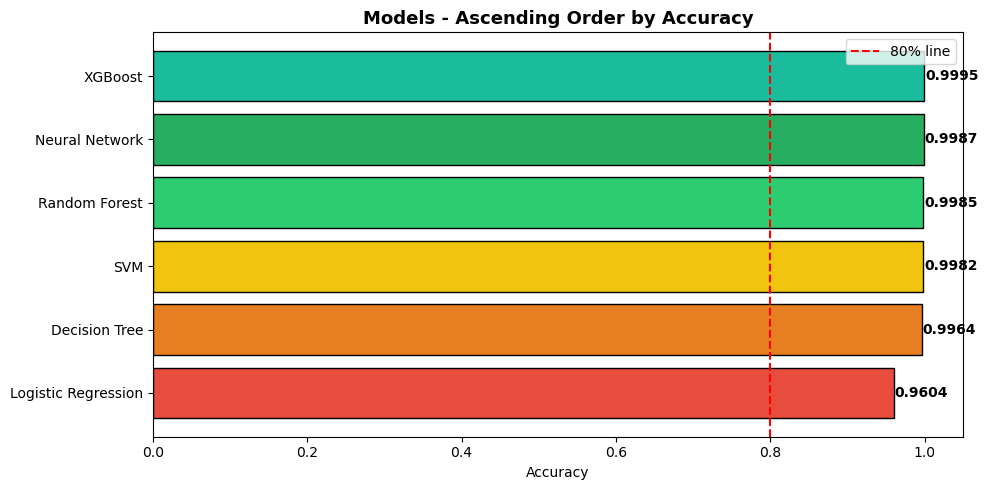

In [31]:
# ─── MODELS ASCENDING ORDER (Best at Bottom) ─────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

models = {
    'Logistic Regression' : y_pred_lr_new,
    'Random Forest'       : y_pred_rf3,
    'Neural Network'      : y_pred_nn3,
    'SVM'                 : y_pred_svm3,
    'Decision Tree'       : y_pred_dt,
    'XGBoost'             : y_pred_xgb,
}

results = []
for name, y_pred in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_test, y_pred, zero_division=0), 4),
    })

# Ascending order 
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Accuracy', ascending=True)
df_results = df_results.reset_index(drop=True)
df_results.index += 1

print('='*70)
print('MODELS - ASCENDING ORDER (Best at Bottom)')
print('='*70)
print(df_results.to_string())
print('='*70)

worst = df_results.iloc[0]['Model']
best  = df_results.iloc[-1]['Model']

print(f'\n Worst Model : {worst}  (Accuracy: {df_results.iloc[0]["Accuracy"]})')
print(f' Best Model  : {best}   (Accuracy: {df_results.iloc[-1]["Accuracy"]})')

# Bar chart - ascending order
plt.figure(figsize=(10, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60', '#1abc9c']
bars = plt.barh(
    df_results['Model'],
    df_results['Accuracy'],
    color=colors[:len(df_results)],
    edgecolor='black'
)
plt.axvline(0.80, color='red', linestyle='--', lw=1.5, label='80% line')
plt.xlabel('Accuracy')
plt.title('Models - Ascending Order by Accuracy', fontsize=13, fontweight='bold')
plt.legend()
for bar, val in zip(bars, df_results['Accuracy']):
    plt.text(
        val + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center', fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()
